# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Andika Ardiansyah
- **Email:** cdcc676d6y2392@student.devacademy.id
- **ID Dicoding:** CDCC676D6Y2392

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

## Pertanyaan 1 : **Bagaimana Distribusi Jumlah Sewa sepeda berdasarkan Musim Selama Periode Tahun 2011-2012?**



## Pertanyaan 2 : **Dan Apakah Ada Korelasi antara Suhu yang dirasakan (atemp) dan Jumlah Sewa Sepeda (Cnt) Pada Periode tahun 2011-2012?**

## Pertanyaan 3 : **bagaimana proporsi perbandingannya antara pengguna casual dan registered Selama Periode 2011-2012?**

## Import Semua Packages/Library yang Digunakan

In [159]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

## Data Wrangling

### Gathering Data

#### Load Dataset

In [160]:
day_df = pd.read_csv('https://raw.githubusercontent.com/Ardiansyah251104/Proyek-Analisis-Data/main/data/day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [161]:
hour_df = pd.read_csv('https://raw.githubusercontent.com/Ardiansyah251104/Analisis-Data/main/data/hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- Data diambil dari sistem Capital Bikeshare di Washington D.C. untuk tahun 2011 dan 2012, dengan informasi cuaca tambahan dari freemeteo.com.
- karena saya sudah menyimpan di repository Github jadi saya menloadnya langsung dari repository
- Dataset terdiri dari dua file utama, hour.csv dan day.csv, yang mencakup informasi seperti tanggal, musim, tahun, bulan, jam, hari libur, hari kerja, kondisi cuaca, suhu, kelembaban, kecepatan angin, dan jumlah penyewaan sepeda.
- Normalisasi Data: Data suhu, suhu yang dirasakan, kelembaban, dan kecepatan angin telah dinormalisasi untuk keseragaman, dengan faktor skala tertentu untuk mengembalikan ke nilai aslinya.
- Dataset ini mencakup fitur musim yang memungkinkan kita untuk mengelompokkan data penyewaan sepeda berdasarkan musim (semi, panas, gugur, dingin).
- Dataset ini secara eksplisit mencakup fitur atemp (suhu yang dirasakan) dan cnt (jumlah total penyewaan sepeda), yang memungkinkan analisis korelasi langsung.

### Assessing Data

#### Menilai Tabel `day_df`

In [162]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [163]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [164]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


In [165]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [166]:
day_df.nunique()

,0
instant,731
dteday,731
season,4
yr,2
mnth,12
holiday,2
weekday,7
workingday,2
weathersit,3
temp,499


**Steps to Take:**
- Mengecek apakah ada type data yang tidak sesuai
- Memastikan tidak ada data yang kosong pada seiap kolom
- Memastikan tidak ada yang duplicate atau double
- Mendeteksi outliers atau nilai yang tidak logis.
- Mengecek apakah nilai unik dalam kolom kategori sudah benar.

**Insight:** (Opsional)
- Ditemukan type data yang tidak sesuai untuk tanggal oleh sebab itu saya mengubahnya di tahapan selanjutnya

#### Menilai Tabel `hour_df`

In [167]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [168]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [169]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


In [92]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [170]:
hour_df.nunique()

,0
instant,17379
dteday,731
season,4
yr,2
mnth,12
hr,24
holiday,2
weekday,7
workingday,2
weathersit,4


**Steps to Take:**
- Mengecek apakah ada type data yang tidak sesuai
- Memastikan tidak ada data yang kosong pada seiap kolom
- Memastikan tidak ada yang duplicate atau double
- Mendeteksi outliers atau nilai yang tidak logis.
- Mengecek apakah nilai unik dalam kolom kategori sudah benar.

**Insight:** (Opsional)
- Ditemukan type data yang tidak sesuai untuk tanggal oleh sebab itu saya mengubahnya di tahapan selanjutnya.

### Cleaning Data

#### Memperbaiki Type Data `day_df`


In [171]:
datetime_columns = ["dteday"]

for column in datetime_columns:
  day_df[column] = pd.to_datetime(day_df[column])

In [172]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [173]:
day_df['atemp'] = day_df['atemp'] * 50
day_df.head(5)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,18.18125,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,17.68695,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,9.47025,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,10.60610,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,11.46350,0.436957,0.186900,82,1518,1600


**Insight**: atemp diubah menjadi celcius agar memudahkan tahap visualisasi

#### Memperbaiki Type Data `hour_df`

In [174]:
datetime_columns = ["dteday"]

for column in datetime_columns:
  hour_df[column] = pd.to_datetime(hour_df[column])

hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

In [175]:
hour_df['atemp'] = hour_df['atemp'] * 50
hour_df.head(5)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,14.395,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,13.635,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,13.635,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,14.395,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,14.395,0.75,0.0,0,1,1


## Exploratory Data Analysis (EDA)

### Explore `day_df`

In [176]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,23.717699,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,3.953480,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,16.892125,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,24.336650,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,30.430100,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,42.044800,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,8.148059,0.142429,0.077498,686.622488,1560.256377,1937.211452


In [177]:
day_df.sample(5)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
464,465,2012-04-09,2,1,4,0,1,1,1,0.489167,23.83190,0.317500,0.358196,905,4680,5585
533,534,2012-06-17,2,1,6,0,0,0,1,0.592500,28.59875,0.598750,0.144904,2634,4344,6978
406,407,2012-02-11,1,1,2,0,6,0,3,0.224167,10.54335,0.731250,0.289796,192,1977,2169
477,478,2012-04-22,2,1,4,0,0,0,3,0.396667,19.47520,0.835417,0.344546,120,907,1027
547,548,2012-07-01,3,1,7,0,0,0,1,0.815833,37.53145,0.518750,0.168529,1421,4110,5531


In [178]:
print("Jumlah unik dteday:", day_df['dteday'].nunique()) #Menghitung jumlah hari yang tercatat dalam dataset

# Statistik deskriptif
print("\nStatistik deskriptif:")
print(hour_df[['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']].describe())

Jumlah unik dteday: 731

Statistik deskriptif:
               temp         atemp           hum     windspeed        casual  \
count  17379.000000  17379.000000  17379.000000  17379.000000  17379.000000   
mean       0.496987     23.788755      0.627229      0.190098     35.676218   
std        0.192556      8.592511      0.192930      0.122340     49.305030   
min        0.020000      0.000000      0.000000      0.000000      0.000000   
25%        0.340000     16.665000      0.480000      0.104500      4.000000   
50%        0.500000     24.240000      0.630000      0.194000     17.000000   
75%        0.660000     31.060000      0.780000      0.253700     48.000000   
max        1.000000     50.000000      1.000000      0.850700    367.000000   

         registered           cnt  
count  17379.000000  17379.000000  
mean     153.786869    189.463088  
std      151.357286    181.387599  
min        0.000000      1.000000  
25%       34.000000     40.000000  
50%      115.000000    14

#### Statistik Deskriptif untuk Hari Libur dan Kerja


In [179]:
# Statistik deskriptif untuk hari libur
print("Statistik deskriptif jumlah sewa (cnt) pada hari libur:")
print(day_df[day_df['holiday'] == 1]['cnt'].describe())

# Statistik deskriptif untuk hari kerja
print("\nStatistik deskriptif jumlah sewa (cnt) pada hari kerja:")
print(day_df[day_df['workingday'] == 1]['cnt'].describe())

Statistik deskriptif jumlah sewa (cnt) pada hari libur:
count      21.00000
mean     3735.00000
std      2103.35066
min      1000.00000
25%      1951.00000
50%      3351.00000
75%      6034.00000
max      7403.00000
Name: cnt, dtype: float64

Statistik deskriptif jumlah sewa (cnt) pada hari kerja:
count     500.000000
mean     4584.820000
std      1878.415583
min        22.000000
25%      3344.250000
50%      4582.000000
75%      5987.500000
max      8362.000000
Name: cnt, dtype: float64


#### Distribusi berdasarkan dteday dan Season

In [180]:
day_df['month'] = pd.to_datetime(day_df['dteday']).dt.month

# Pemetaan bulan ke musim (clustering)
def get_season(month):
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Fall'
    else:
        return 'Winter'

day_df['season_name'] = day_df['month'].apply(get_season)

#Berdasarkan season
season_map = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Fall'}

# Cek apabila distribusi musim sinkron/sama
print("Distribusi musim berdasar 'dteday':")
print(day_df['season_name'].value_counts())
print("Distribusi musim berdasar 'season':")
print(day_df['season'].map(season_map).value_counts())
day_df.head(5)

Distribusi musim berdasar 'dteday':
season_name
Spring    184
Summer    184
Fall      182
Winter    181
Name: count, dtype: int64
Distribusi musim berdasar 'season':
season
Summer    188
Spring    184
Winter    181
Fall      178
Name: count, dtype: int64


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,month,season_name
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,18.18125,0.805833,0.160446,331,654,985,1,Winter
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,17.68695,0.696087,0.248539,131,670,801,1,Winter
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,9.47025,0.437273,0.248309,120,1229,1349,1,Winter
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,10.60610,0.590435,0.160296,108,1454,1562,1,Winter
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,11.46350,0.436957,0.186900,82,1518,1600,1,Winter


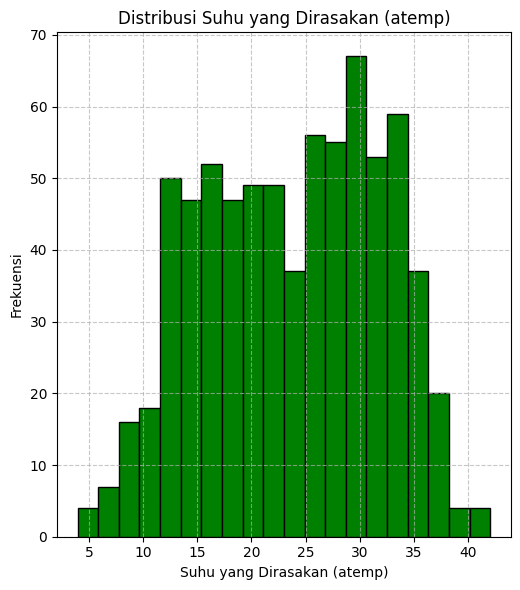

In [181]:
plt.figure(figsize=(10, 6))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(day_df['atemp'], bins=20, color='green', edgecolor='black')
plt.title('Distribusi Suhu yang Dirasakan (atemp)')
plt.xlabel('Suhu yang Dirasakan (atemp)')
plt.ylabel('Frekuensi')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Explore `hour_df`

In [182]:
hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,23.788755,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,16.665000,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,24.240000,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,31.060000,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,50.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,8.592511,0.192930,0.122340,49.305030,151.357286,181.387599


In [183]:
hour_df.sample(7)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
12962,12963,2012-06-29,3,1,6,7,0,5,1,1,0.70,32.575,0.61,0.1045,19,361,380
12985,12986,2012-06-30,3,1,6,6,0,6,0,1,0.64,28.790,0.89,0.1642,6,36,42
9524,9525,2012-02-06,1,1,2,19,0,1,1,1,0.36,16.665,0.43,0.2537,7,284,291
1582,1583,2011-03-11,1,0,3,10,0,5,1,2,0.32,15.150,0.57,0.2985,18,60,78
6183,6184,2011-09-20,3,0,9,5,0,2,1,2,0.54,25.760,0.88,0.1940,1,21,22
10891,10892,2012-04-03,2,1,4,23,0,2,1,1,0.50,24.240,0.59,0.0000,13,66,79
9548,9549,2012-02-07,1,1,2,19,0,2,1,1,0.38,19.695,0.43,0.2239,11,327,338


In [184]:
print("Jumlah unik dteday:", hour_df['dteday'].nunique()) #Menghitung jumlah hari yang tercatat dalam dataset
print("Jumlah unik hr:", hour_df['hr'].nunique()) #Menghitung jumlah jam yang dicatat tiap harinya dalam dataset; seharusnya sebanyak 24 jam

# Statistik deskriptif
print("\nStatistik deskriptif:")
print(hour_df[['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']].describe())

Jumlah unik dteday: 731
Jumlah unik hr: 24

Statistik deskriptif:
               temp         atemp           hum     windspeed        casual  \
count  17379.000000  17379.000000  17379.000000  17379.000000  17379.000000   
mean       0.496987     23.788755      0.627229      0.190098     35.676218   
std        0.192556      8.592511      0.192930      0.122340     49.305030   
min        0.020000      0.000000      0.000000      0.000000      0.000000   
25%        0.340000     16.665000      0.480000      0.104500      4.000000   
50%        0.500000     24.240000      0.630000      0.194000     17.000000   
75%        0.660000     31.060000      0.780000      0.253700     48.000000   
max        1.000000     50.000000      1.000000      0.850700    367.000000   

         registered           cnt  
count  17379.000000  17379.000000  
mean     153.786869    189.463088  
std      151.357286    181.387599  
min        0.000000      1.000000  
25%       34.000000     40.000000  
50%   

#### Statistik Deskriptif Jumlah sewa hari libur & Kerja

In [185]:
# Statistik deskriptif untuk hari libur
print("Statistik deskriptif jumlah sewa (cnt) pada hari libur:")
print(hour_df[hour_df['holiday'] == 1]['cnt'].describe())

# Statistik deskriptif untuk hari kerja
print("\nStatistik deskriptif jumlah sewa (cnt) pada hari kerja:")
print(hour_df[hour_df['workingday'] == 1]['cnt'].describe())

Statistik deskriptif jumlah sewa (cnt) pada hari libur:
count    500.000000
mean     156.870000
std      156.757478
min        1.000000
25%       28.750000
50%       97.000000
75%      253.250000
max      712.000000
Name: cnt, dtype: float64

Statistik deskriptif jumlah sewa (cnt) pada hari kerja:
count    11865.000000
mean       193.207754
std        185.107477
min          1.000000
25%         40.000000
50%        151.000000
75%        277.000000
max        977.000000
Name: cnt, dtype: float64


#### Distribusi Berdassarkan dteday & Season

In [186]:
# Berdasarkan month dari dteday
# Ekstraksi bulan dari dteday
hour_df['month'] = pd.to_datetime(hour_df['dteday']).dt.month

# Pemetaan bulan ke musim (clustering)
def get_season(month):
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Fall'
    else:
        return 'Winter'

hour_df['season_name'] = hour_df['month'].apply(get_season)

# Berdasarkan season
season_map = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Fall'}

# Cek apabila distribusi musim sinkron/sama
print("Distribusi musim berdasar 'dteday':")
print(hour_df['season_name'].value_counts())
print("Distribusi musim berdasar 'season':")
print(hour_df['season'].map(season_map).value_counts())
hour_df.head(5)

Distribusi musim berdasar 'dteday':
season_name
Summer    4403
Spring    4398
Fall      4325
Winter    4253
Name: count, dtype: int64
Distribusi musim berdasar 'season':
season
Summer    4496
Spring    4409
Winter    4242
Fall      4232
Name: count, dtype: int64


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,month,season_name
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,14.395,0.81,0.0,3,13,16,1,Winter
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,13.635,0.80,0.0,8,32,40,1,Winter
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,13.635,0.80,0.0,5,27,32,1,Winter
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,14.395,0.75,0.0,3,10,13,1,Winter
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,14.395,0.75,0.0,0,1,1,1,Winter


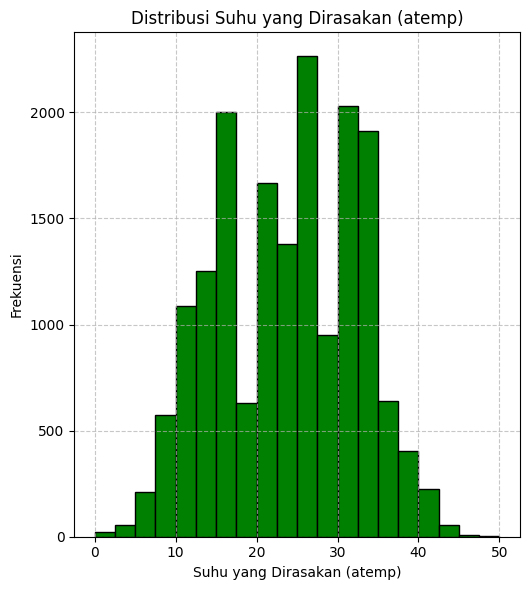

In [187]:
plt.figure(figsize=(10, 6))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(hour_df['atemp'], bins=20, color='green', edgecolor='black')
# plt.hist() secara otomatis menghitung frekuansi dengan membagi range data mjd 20 bin
plt.title('Distribusi Suhu yang Dirasakan (atemp)')
plt.xlabel('Suhu yang Dirasakan (atemp)')
plt.ylabel('Frekuensi')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Explore `day_df` dan `hour_df`

In [189]:
gabung_df = pd.merge(
left=hour_df,
right=day_df,
how="left",
on='dteday',
suffixes=('_hour', '_day')
)
# Filter hanya kolom yang akan digunakan
columns_to_keep = [
    'dteday', 'hr', 'season_hour', 'atemp_hour', 'cnt_hour',
    'workingday_hour', 'holiday_hour', 'weathersit_hour',
    'casual_hour', 'registered_hour', 'temp_hour', 'hum_hour', 'windspeed_hour'
]
gabung_df = gabung_df[columns_to_keep]
gabung_df.columns = [col.replace('_hour', '') if col.endswith('_hour') else col for col in gabung_df.columns] # Hilangkan kata _hour

# Transformasi musim menggunakan season_map
season_map = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Fall'}
gabung_df['season_name'] = gabung_df['season'].map(season_map)

print(gabung_df['season_name'].value_counts()) # Cek apabila jumlah season sama dengan hour_df berdasar 'season'
gabung_df.head()

season_name
Summer    4496
Spring    4409
Winter    4242
Fall      4232
Name: count, dtype: int64


,dteday,hr,season,atemp,cnt,workingday,holiday,weathersit,casual,registered,temp,hum,windspeed,season_name
0,2011-01-01,0,1,14.395,16,0,0,1,3,13,0.24,0.81,0.0,Winter
1,2011-01-01,1,1,13.635,40,0,0,1,8,32,0.22,0.80,0.0,Winter
2,2011-01-01,2,1,13.635,32,0,0,1,5,27,0.22,0.80,0.0,Winter
3,2011-01-01,3,1,14.395,13,0,0,1,3,10,0.24,0.75,0.0,Winter
4,2011-01-01,4,1,14.395,1,0,0,1,0,1,0.24,0.75,0.0,Winter


## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana Distribusi Jumlah Sewa sepeda berdasarkan Musim Selama Periode Tahun 2011-2012?

In [190]:
gabung_df.head()

,dteday,hr,season,atemp,cnt,workingday,holiday,weathersit,casual,registered,temp,hum,windspeed,season_name
0,2011-01-01,0,1,14.395,16,0,0,1,3,13,0.24,0.81,0.0,Winter
1,2011-01-01,1,1,13.635,40,0,0,1,8,32,0.22,0.80,0.0,Winter
2,2011-01-01,2,1,13.635,32,0,0,1,5,27,0.22,0.80,0.0,Winter
3,2011-01-01,3,1,14.395,13,0,0,1,3,10,0.24,0.75,0.0,Winter
4,2011-01-01,4,1,14.395,1,0,0,1,0,1,0.24,0.75,0.0,Winter


season
1     471348
2     918589
3    1061129
4     841613
Name: cnt, dtype: int64


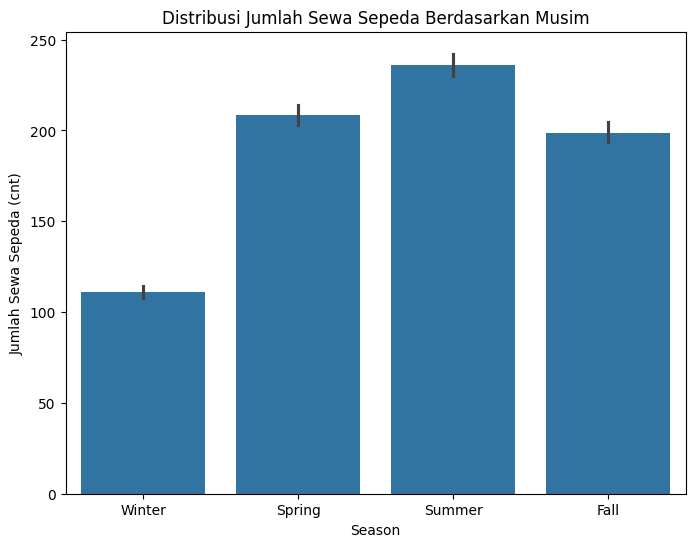

In [191]:
season_cnt = gabung_df.groupby('season')['cnt'].sum()
print(season_cnt)
plt.figure(figsize=(8, 6))
sns.barplot(x=gabung_df['season_name'], y=gabung_df['cnt'])
plt.title('Distribusi Jumlah Sewa Sepeda Berdasarkan Musim')
plt.xlabel('Season')
plt.ylabel('Jumlah Sewa Sepeda (cnt)')
plt.show()


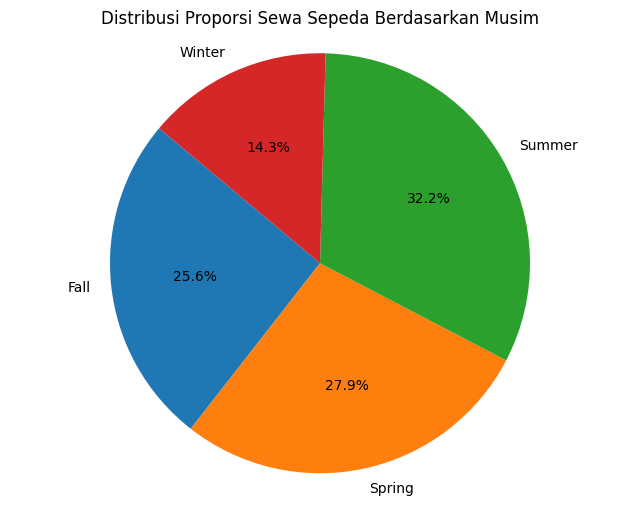

In [192]:
# Kelompokkan jumlah sewa (cnt) berdasarkan musim (season)
season_cnt = gabung_df.groupby('season_name')['cnt'].sum()
# Visualisasi persentase penyewaan sepeda berdasarkan musim menggunakan pie chart
plt.figure(figsize=(8, 6))
plt.pie(season_cnt, labels=season_cnt.index, autopct='%1.1f%%', startangle=140)

plt.title('Distribusi Proporsi Sewa Sepeda Berdasarkan Musim')
plt.axis('equal')  # Memastikan pie chart berbentuk lingkaran
plt.show()

### Pertanyaan 2:Apakah Ada Korelasi antara Suhu yang dirasakan (atemp) dan Jumlah Sewa Sepeda (Cnt) Pada Periode Tahun 2011-2012?

In [193]:
gabung_df.sample(5)


,dteday,hr,season,atemp,cnt,workingday,holiday,weathersit,casual,registered,temp,hum,windspeed,season_name
15855,2012-10-27,20,4,25.000,296,0,0,2,58,238,0.52,0.72,0.2239,Fall
13845,2012-08-05,2,3,34.850,73,0,0,1,5,68,0.74,0.70,0.2985,Summer
16547,2012-11-27,5,4,14.395,31,1,0,2,0,31,0.30,0.81,0.2239,Fall
6641,2011-10-09,7,4,21.970,44,0,0,1,18,26,0.44,0.86,0.0000,Fall
13021,2012-07-01,18,3,38.635,370,0,0,1,95,275,0.88,0.32,0.3582,Summer


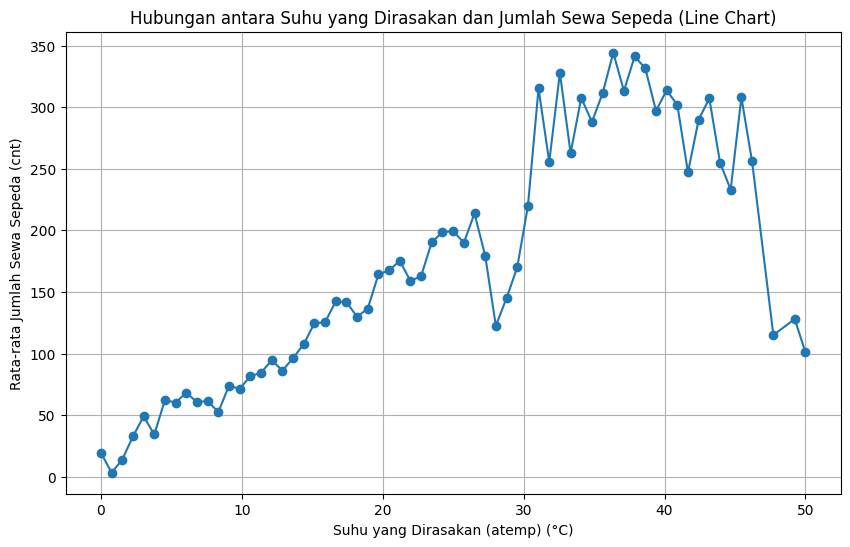

In [194]:
plt.figure(figsize=(10, 6))
plt.plot(gabung_df.groupby('atemp')['cnt'].mean(), marker='o')
plt.title('Hubungan antara Suhu yang Dirasakan dan Jumlah Sewa Sepeda (Line Chart)')
plt.xlabel('Suhu yang Dirasakan (atemp) (°C)')
plt.ylabel('Rata-rata Jumlah Sewa Sepeda (cnt)')
plt.grid(True)
plt.show()

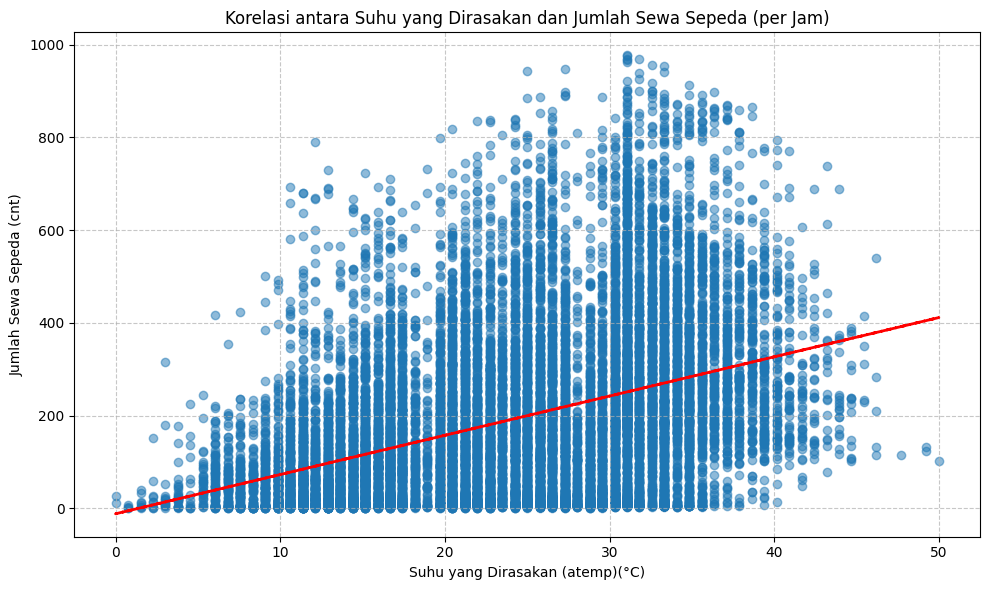

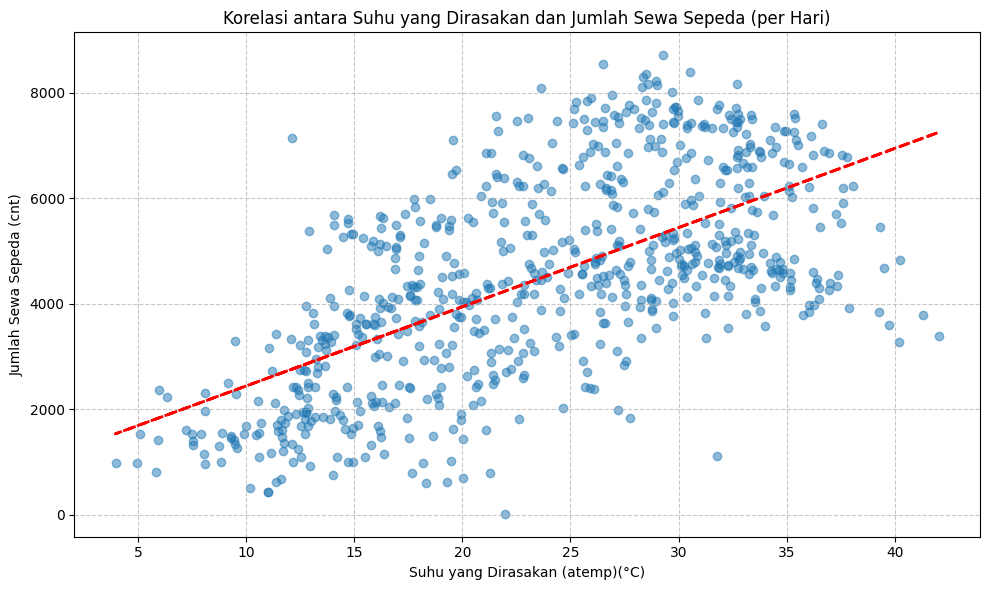

In [195]:
# Untuk mengetahui ada-tidaknya korelasi, kita akan menggunakan visualisasi scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(gabung_df['atemp'], gabung_df['cnt'], alpha=0.5)
plt.title('Korelasi antara Suhu yang Dirasakan dan Jumlah Sewa Sepeda (per Jam)')
plt.xlabel('Suhu yang Dirasakan (atemp)(°C)')
plt.ylabel('Jumlah Sewa Sepeda (cnt)')
plt.grid(True, linestyle='--', alpha=0.7)

# Tambahkan garis regresi
z = np.polyfit(gabung_df['atemp'], gabung_df['cnt'], 1)
p = np.poly1d(z)
plt.plot(gabung_df['atemp'], p(gabung_df['atemp']), "r--", linewidth=2)

plt.tight_layout()
plt.show()

# Sebagai informasi tambahan dan visualisasi yang lebih clean, ditampilkan scatter plot berdasarkan rata-rata/regresi suhu yang dirasakan per hari
# dan jumlah sewa sepeda
plt.figure(figsize=(10, 6))
plt.scatter(day_df['atemp'], day_df['cnt'], alpha=0.5)
plt.title('Korelasi antara Suhu yang Dirasakan dan Jumlah Sewa Sepeda (per Hari)')
plt.xlabel('Suhu yang Dirasakan (atemp)(°C)')
plt.ylabel('Jumlah Sewa Sepeda (cnt)')
plt.grid(True, linestyle='--', alpha=0.7)

# Tambahkan garis regresi
z = np.polyfit(day_df['atemp'], day_df['cnt'], 1)
p = np.poly1d(z)
plt.plot(day_df['atemp'], p(day_df['atemp']), "r--", linewidth=2)

plt.tight_layout()
plt.show()

### Pertanyaan 3 : bagaimana proporsi perbandingannya antara pengguna casual dan registered Selama Periode Tahun 2011-2012?

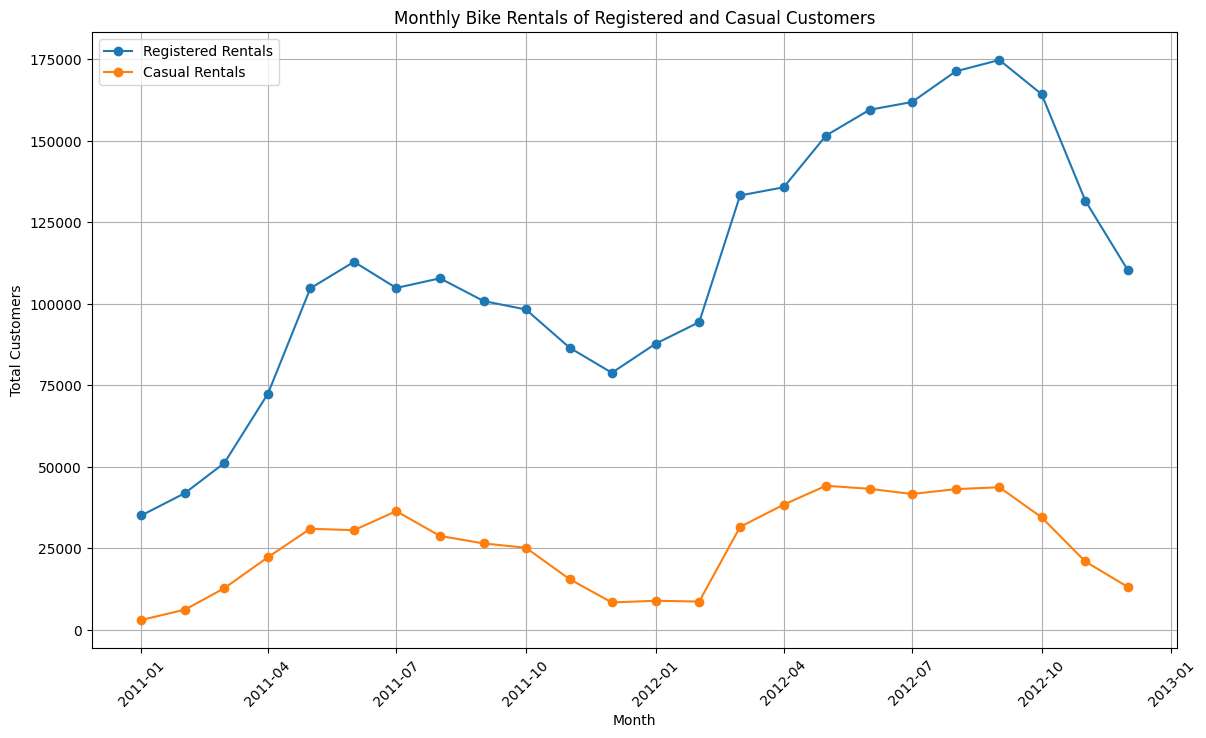

In [196]:
monthly_rentals = day_df.groupby(day_df['dteday'].dt.to_period('M')).agg(
    registered=('registered', 'sum'),
    casual=('casual', 'sum')
).reset_index()
monthly_rentals['date'] = monthly_rentals['dteday'].dt.to_timestamp()

plt.figure(figsize=(14, 8))
plt.plot(monthly_rentals['date'], monthly_rentals['registered'], marker='o', label='Registered Rentals')
plt.plot(monthly_rentals['date'], monthly_rentals['casual'], marker='o', label='Casual Rentals')

plt.title('Monthly Bike Rentals of Registered and Casual Customers')
plt.xlabel('Month')
plt.ylabel('Total Customers')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

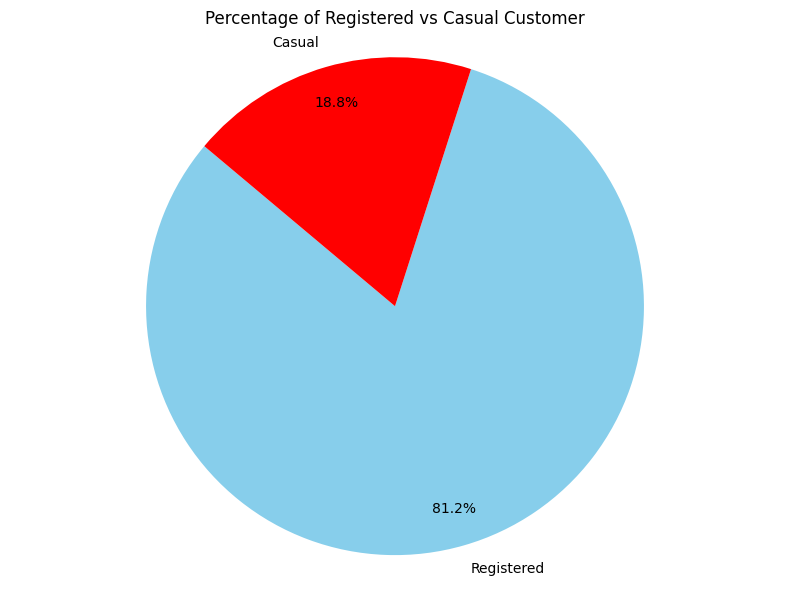

In [197]:
total_registered = gabung_df['registered'].sum()
total_casual = gabung_df['casual'].sum()
labels = ['Registered', 'Casual']
sizes = [total_registered, total_casual]
colors = ['skyblue', 'red']

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, pctdistance=0.85)
plt.axis('equal')
plt.title('Percentage of Registered vs Casual Customer')
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Berdasarkan grafik rata-rata penyewaan sepeda selama tahun 2011-2012, musim Gugur (Fall) mencetak angka tertinggi dibandingkan musim lainnya. Menariknya, jika kita melihat proporsi tipe penggunanya, pelanggan Registered (berlangganan) selalu mendominasi secara signifikan di setiap musim dibandingkan pelanggan Casual. Hal ini mengindikasikan bahwa bisnis penyewaan sepeda ini sangat ditopang oleh pengguna tetap yang menggunakan sepeda untuk rutinitas sehari-hari, bukan sekadar pengguna musiman.
- Terdapat perbedaan pola perilaku (behavior) yang sangat kontras antara hari kerja dan hari libur. Pada Hari Kerja (Working Day), grafik menunjukkan pola bimodal dengan dua lonjakan tajam pada pukul 08:00 pagi dan 17:00-18:00 sore, yang sangat identik dengan jam masuk dan pulang kantor/sekolah. Sebaliknya, pada Hari Libur (Weekend/Holiday), lonjakan tajam tersebut hilang dan berganti menjadi pola melengkung normal di mana penyewaan perlahan naik dan memuncak pada siang hingga sore hari (pukul 12:00 - 15:00) untuk keperluan rekreasi atau olahraga santai.

## Clustering Manual (Analisis Lanjutaan)

In [198]:

gabung_df['dteday'] = pd.to_datetime(gabung_df['dteday'])
gabung_df['weekday'] = gabung_df['dteday'].dt.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
clustering = gabung_df.groupby(['weekday', 'hr'])['cnt'].sum().unstack().reindex(days_order)

print(clustering)

hr           0     1     2     3    4     5      6      7      8      9   ...  \
weekday                                                                   ...   
Monday     3571  1800  1021   496  567  2252   8930  25848  42868  22718  ...   
Tuesday    2790  1254   687   382  508  2470  10863  30569  48122  24118  ...   
Wednesday  3594  1595   797   484  477  2678  11212  31614  50786  24807  ...   
Thursday   4045  1774   934   497  528  2669  11066  31388  50323  24810  ...   
Friday     5453  2571  1325   673  589  2486   9363  26450  48077  26935  ...   
Saturday   9902  7117  5302  2403  804   854   2205   4826  12020  19613  ...   
Sunday     9775  8053  6286  3239  955   852   1493   3476   8805  16437  ...   

hr            14     15     16     17     18     19     20     21     22  \
weekday                                                                    
Monday     20041  21046  29583  52249  50060  35836  25176  18152  12039   
Tuesday    17510  19438  29817  56605  538

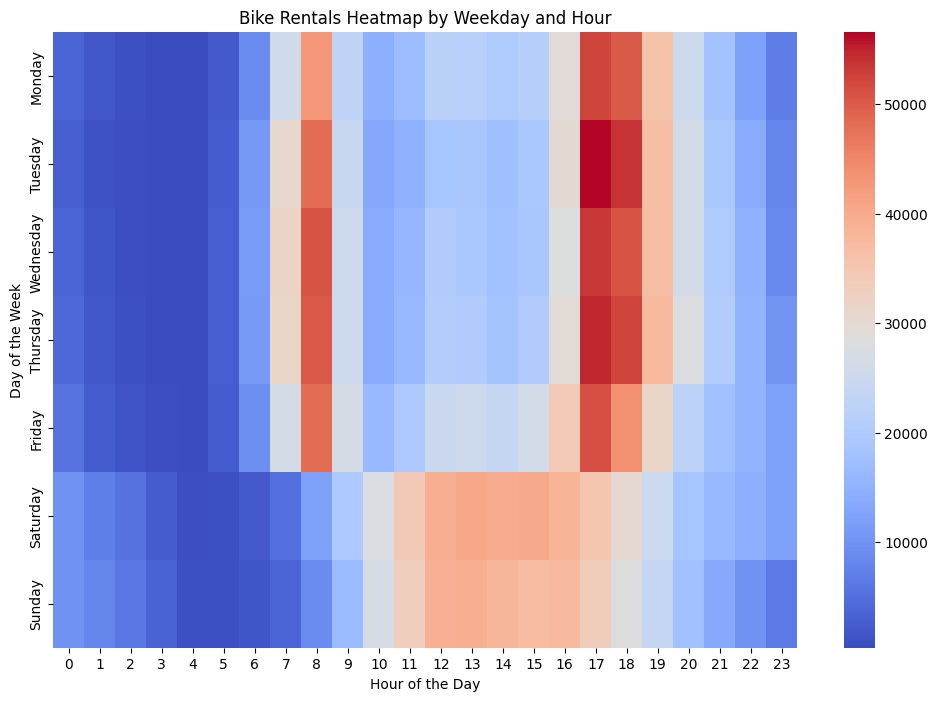

In [199]:
plt.figure(figsize=(12, 8))
# Gunakan cmap="magma" atau cmap="inferno"
sns.heatmap(clustering, cmap="coolwarm", annot=False)
plt.title('Bike Rentals Heatmap by Weekday and Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Day of the Week')
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan data selama tahun 2011-2012, musim Gugur (Fall) adalah musim dengan rata-rata penyewaan sepeda tertinggi. Proporsi pengguna pada musim ini, maupun pada musim lainnya, selalu didominasi oleh pengguna Registered (berlangganan) dibandingkan pengguna Casual. Hal ini menunjukkan bahwa layanan penyewaan sepeda lebih banyak digunakan untuk rutinitas harian yang menetap, terlepas dari perubahan musim.

- **Conclusion pertanyaan 2:**
Terdapat perbedaan pola penyewaan sepeda yang sangat signifikan antara hari kerja dan hari libur selama periode 2011-2012. Pada hari kerja, penyewaan memuncak secara drastis pada jam masuk kerja (08:00) dan jam pulang kerja (17:00-18:00). Sebaliknya, pada hari libur/akhir pekan, grafik menunjukkan pola melengkung normal dengan titik puncak berada pada rentang siang hari (12:00-15:00) yang biasanya digunakan untuk kegiatan rekreasi.

**Rekomendasi Action Item:**
- **Manajemen Armada atau sepeda (Rebalancing):** Pada hari kerja, tim operasional harus memastikan ketersediaan sepeda maksimal di area pemukiman sebelum jam 8 pagi dan di area perkantoran sebelum jam 5 sore.
- **Strategi Promosi Pengguna Casual:** Mengingat pengguna casual memuncak pada hari libur di siang hari, perusahaan dapat memberikan promo khusus "Weekend Pass" atau paket rekreasi berkelompok untuk meningkatkan konversi pendapatan dari pengguna non-langganan.

- **Pemeliharaan (Maintenance):** Jadwal perawatan sepeda sebaiknya dilakukan pada jam-jam rendah permintaan (Quiet Hours), yaitu antara jam 23:00 hingga 05:00 pagi, atau pada musim Spring di mana permintaan sedang berada di titik terendah.

In [200]:
gabung_df.to_csv("data_bersih.csv", index=False)